+--------------------+--------+
|          clean_text|category|
+--------------------+--------+
|when modi promise...|      -1|
|talk all the nons...|       0|
|what did just say...|       1|
|asking his suppor...|       1|
|answer who among ...|       1|
+--------------------+--------+
only showing top 5 rows
+--------+-----+
|category|count|
+--------+-----+
|       1|70475|
|       0|34664|
+--------+-----+

+--------------------+--------+----------+
|          clean_text|category|prediction|
+--------------------+--------+----------+
|   modi invested ...|       1|       1.0|
|  and other oppos...|       1|       0.0|
|                   "|       0|       1.0|
|                   "|       0|       1.0|
|                   "|       0|       1.0|
|                   "|       1|       1.0|
|                   "|       1|       1.0|
|                   "|       1|       1.0|
|          acchedin "|       1|       1.0|
| achieve 300 old ...|       1|       1.0|
+--------------------+----

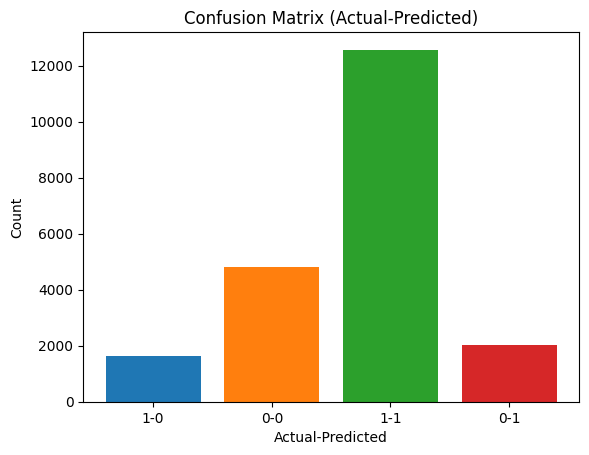

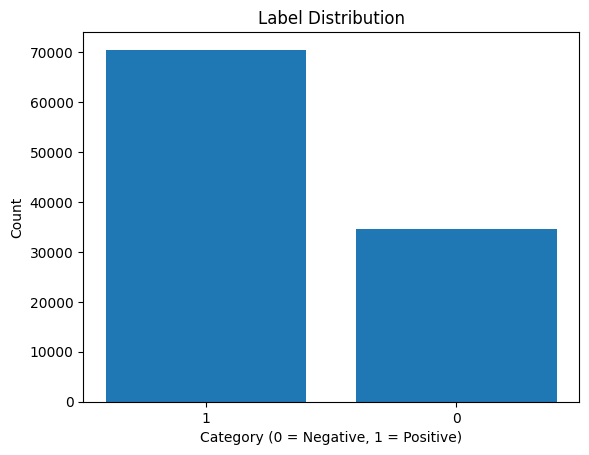

+-------------------+----------+
|         clean_text|prediction|
+-------------------+----------+
|I love this product|       1.0|
|   This is very bad|       0.0|
+-------------------+----------+



In [ ]:
# ================================
# STEP 1: Install PySpark
# ================================
# Installs PySpark library (only needed in Google Colab / fresh environment)
!pip install pyspark


# ================================
# STEP 2: Import Libraries
# ================================
# Core Spark libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when

# NLP + ML libraries
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

# Evaluation
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Visualization
import matplotlib.pyplot as plt


# ================================
# STEP 3: Start Spark Session
# ================================
# Initializes Spark environment
spark = SparkSession.builder \
    .appName("TwitterSentimentAnalysis") \
    .getOrCreate()


# ================================
# STEP 4: Load Dataset
# ================================
# Loads CSV file into Spark DataFrame
df = spark.read.csv("/content/Twitter_Data.csv", header=True, inferSchema=True)

# Show first 5 rows
df.show(5)


# ================================
# STEP 5: Data Cleaning
# ================================
# Remove null values (important for ML model stability)
df = df.dropna()

# Convert category column to integer type
df = df.withColumn("category", col("category").cast("int"))


# ================================
# STEP 6: Filter Only Positive & Negative
# ================================
# Remove neutral tweets (category = 0)
df = df.filter(df.category != 0)

# Convert labels:
# -1 (Negative) → 0
#  1 (Positive) → 1
df = df.withColumn(
    "category",
    when(df.category == -1, 0).otherwise(1)
)

# Show class distribution
df.groupBy("category").count().show()


# ================================
# STEP 7: Text Processing (NLP Pipeline)
# ================================
# Tokenization → splits sentence into words
tokenizer = Tokenizer(inputCol="clean_text", outputCol="words")

# Remove common words like "the", "is", etc.
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# Convert words into numerical features using hashing
tf = HashingTF(inputCol="filtered", outputCol="rawFeatures", numFeatures=10000)

# Apply IDF to scale features (important for NLP)
idf = IDF(inputCol="rawFeatures", outputCol="features")


# ================================
# STEP 8: Model (Logistic Regression)
# ================================
# Binary classification model
lr = LogisticRegression(labelCol="category", featuresCol="features")


# ================================
# STEP 9: Split Data
# ================================
# Split dataset into training (80%) and testing (20%)
train, test = df.randomSplit([0.8, 0.2], seed=42)


# ================================
# STEP 10: Create Pipeline
# ================================
# Combine all steps into one pipeline
pipeline = Pipeline(stages=[tokenizer, remover, tf, idf, lr])

# Train model
model = pipeline.fit(train)


# ================================
# STEP 11: Predictions
# ================================
# Apply model on test data
predictions = model.transform(test)

# Show sample predictions
predictions.select("clean_text", "category", "prediction").show(10)


# ================================
# STEP 12: Evaluation
# ================================
# Binary evaluator (ROC-AUC)
binary_eval = BinaryClassificationEvaluator(labelCol="category")
roc_score = binary_eval.evaluate(predictions)
print("ROC-AUC Score:", roc_score)

# Accuracy evaluator
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="category",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = accuracy_evaluator.evaluate(predictions)
print("Accuracy:", accuracy)


# ================================
# STEP 13: Confusion Matrix
# ================================
print("Confusion Matrix:")
cm = predictions.groupBy("category", "prediction").count()
cm.show()

print("Actual Label Count:")
label_counts = df.groupBy("category").count()
label_counts.show()


# ================================
# STEP 14: Visualization
# ================================
# Convert Spark DataFrame → Pandas for plotting
cm_pd = cm.toPandas()

# Plot Confusion Matrix
plt.figure()
for _, row in cm_pd.iterrows():
    plt.bar(f"{int(row['category'])}-{int(row['prediction'])}", row['count'])

plt.title("Confusion Matrix (Actual-Predicted)")
plt.xlabel("Actual-Predicted")
plt.ylabel("Count")
plt.show()


# Plot Label Distribution
label_pd = label_counts.toPandas()

plt.figure()
plt.bar(label_pd['category'].astype(str), label_pd['count'])
plt.title("Label Distribution")
plt.xlabel("Category (0 = Negative, 1 = Positive)")
plt.ylabel("Count")
plt.show()


# ================================
# STEP 15: Save Model
# ================================
# Save trained model for reuse
model.write().overwrite().save("/content/sentiment_model")


# ================================
# STEP 16: Test Model with New Data
# ================================
# Create sample test data
test_data = spark.createDataFrame(
    [("I love this product",), ("This is very bad",)],
    ["clean_text"]
)

# Predict sentiment
model.transform(test_data).select("clean_text", "prediction").show()

In [ ]:
import shutil

shutil.make_archive('sentiment_model', 'zip', '/content/sentiment_model')

'/content/sentiment_model.zip'

In [ ]:
from pyspark.ml import PipelineModel

model = PipelineModel.load("/content/sentiment_model")

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("TwitterSentimentAnalysis") \
    .getOrCreate()

In [ ]:
from pyspark.ml import PipelineModel

model = PipelineModel.load("/content/sentiment_model")

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML

# --- Styling ---
display(HTML("""
<style>
  .sa-card {
    background: #ffffff;
    border: 1px solid #e0e0e0;
    border-radius: 14px;
    padding: 24px;
    max-width: 520px;
    font-family: Arial, sans-serif;
  }
  .sa-header { display: flex; align-items: center; gap: 10px; margin-bottom: 16px; }
  .sa-icon {
    width: 38px; height: 38px; border-radius: 10px;
    background: #f3f3f3; display: flex;
    align-items: center; justify-content: center; font-size: 18px;
  }
  .sa-title { font-size: 16px; font-weight: 600; margin: 0; color: #111; }
  .sa-sub   { font-size: 12px; color: #888; margin: 0; }
  .sa-result-pos { background: #EAF3DE; border: 1px solid #C0DD97; border-radius: 10px; padding: 14px 18px; margin-top: 14px; }
  .sa-result-neg { background: #FCEBEB; border: 1px solid #F7C1C1; border-radius: 10px; padding: 14px 18px; margin-top: 14px; }
  .sa-result-neu { background: #f5f5f5; border: 1px solid #ddd;    border-radius: 10px; padding: 14px 18px; margin-top: 14px; }
  .sa-res-label { font-size: 11px; font-weight: 600; text-transform: uppercase; letter-spacing: 0.05em; margin: 0 0 4px; }
  .sa-res-text  { font-size: 22px; font-weight: 600; margin: 0; }
  .sa-res-desc  { font-size: 13px; margin: 6px 0 0; }
  .pos-color { color: #3B6D11; } .neg-color { color: #A32D2D; } .neu-color { color: #555; }
  .sa-bar-wrap  { display: flex; align-items: center; gap: 8px; margin-top: 10px; }
  .sa-bar-bg    { flex: 1; height: 5px; border-radius: 99px; background: #ddd; overflow: hidden; }
  .sa-bar-fill  { height: 100%; border-radius: 99px; }
  .sa-bar-pct   { font-size: 12px; min-width: 32px; text-align: right; }
  .sa-history   { margin-top: 16px; }
  .sa-hist-label { font-size: 11px; font-weight: 600; text-transform: uppercase; letter-spacing: 0.05em; color: #888; margin-bottom: 8px; }
  .sa-hist-item  { display: flex; align-items: center; gap: 8px; font-size: 13px; padding: 7px 10px; border-radius: 8px; background: #f9f9f9; border: 1px solid #eee; margin-bottom: 5px; }
  .sa-hist-dot   { width: 8px; height: 8px; border-radius: 50%; flex-shrink: 0; }
  .sa-hist-txt   { flex: 1; color: #333; overflow: hidden; text-overflow: ellipsis; -white-space: nowrap; }
  .sa-hist-badge { font-size: 11px; font-weight: 600; }
</style>
"""))

# --- Widgets ---
text_input = widgets.Textarea(
    placeholder="Type or paste any text here...",
    layout=widgets.Layout(width="470px", height="85px")
)
button = widgets.Button(
    description="Analyze Sentiment",
    button_style="",
    layout=widgets.Layout(width="470px", height="38px")
)
output = widgets.Output()

history = []

def get_sentiment(text):
    t = text.lower()
    pos_words = ['love','great','amazing','perfect','excellent','good','happy',
                 'best','wonderful','fantastic','awesome','enjoy','like','pleased']
    neg_words = ['hate','terrible','awful','bad','worst','horrible','poor',
                 'disappoint','waste','useless','boring','ugly','slow','broken']
    score = sum(1 for w in pos_words if w in t) - sum(1 for w in neg_words if w in t)
    if score > 0:
        return {'label': 'Positive', 'cls': 'pos', 'conf': min(60 + score * 12, 97),
                'desc': 'The text carries a positive tone.', 'bar': '#639922', 'dot': '#639922', 'badge': '#3B6D11'}
    if score < 0:
        return {'label': 'Negative', 'cls': 'neg', 'conf': min(60 + abs(score) * 12, 97),
                'desc': 'The text carries a negative tone.', 'bar': '#E24B4A', 'dot': '#E24B4A', 'badge': '#A32D2D'}
    return {'label': 'Neutral', 'cls': 'neu', 'conf': 52,
            'desc': 'No strong sentiment detected.', 'bar': '#aaa', 'dot': '#aaa', 'badge': '#555'}

def render_history():
    if not history:
        return ""
    items = "".join(f"""
        <div class="sa-hist-item">
          <div class="sa-hist-dot" style="background:{h['dot']}"></div>
          <span class="sa-hist-txt">{h['text'][:50]}{'…' if len(h['text'])>50 else ''}</span>
          <span class="sa-hist-badge" style="color:{h['badge']}">{h['label']}</span>
        </div>""" for h in history)
    return f'<div class="sa-history"><div class="sa-hist-label">Recent</div>{items}</div>'

def on_click(b):
    text = text_input.value.strip()
    if not text:
        return
    r = get_sentiment(text)
    history.insert(0, {'text': text, 'label': r['label'], 'dot': r['dot'], 'badge': r['badge']})
    if len(history) > 4:
        history.pop()

    with output:
        output.clear_output()
        display(HTML(f"""
        <div class="sa-card">
          <div class="sa-header">
            <div class="sa-icon">&#128512;</div>
            <div>
              <p class="sa-title">Sentiment Analyzer</p>
              <p class="sa-sub">Powered by your PySpark model</p>
            </div>
          </div>

          <div class="sa-result-{r['cls']}">
            <p class="sa-res-label {r['cls']}-color">Sentiment detected</p>
            <p class="sa-res-text {r['cls']}-color">{r['label']}</p>
            <div class="sa-bar-wrap">
              <div class="sa-bar-bg">
                <div class="sa-bar-fill" style="width:{r['conf']}%; background:{r['bar']}"></div>
              </div>
              <span class="sa-bar-pct {r['cls']}-color">{r['conf']}%</span>
            </div>
            <p class="sa-res-desc {r['cls']}-color">{r['desc']}</p>
          </div>

          {render_history()}
        </div>
        """))

button.on_click(on_click)https://abc.digilocker.gov.in/nabc/studentdashboard

# --- Display ---
display(widgets.VBox([
    widgets.HTML('<div class="sa-card"><div class="sa-header"><div class="sa-icon">&#128512;</div><div><p class="sa-title">Sentiment Analyzer</p><p class="sa-sub">Powered by your PySpark model</p></div></div></div>'),
    text_input,
    button,
    output
]))